# Trader Performance vs Bitcoin Market Sentiment

This notebook checks the relationship between Hyperliquid trader performance and Bitcoin Fear/Greed market sentiment.

**Datasets used:**
- `historical_data.csv`
- `fear_greed_index.csv`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the two required files
trader_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

print('Trader data shape:', trader_df.shape)
print('Sentiment data shape:', sentiment_df.shape)
print('Trader columns:', trader_df.columns.tolist())
print('Sentiment columns:', sentiment_df.columns.tolist())

Trader data shape: (130534, 16)
Sentiment data shape: (2644, 4)
Trader columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment columns: ['timestamp', 'value', 'classification', 'date']


/tmp/ipykernel_18106/3801168342.py:6: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader_df = pd.read_csv('historical_data.csv')


## 1. Clean column names

This cell keeps the code simple but makes the column names easier to use.


In [ ]:
# Remove extra spaces from column names
trader_df.columns = trader_df.columns.str.strip()
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()

# Rename common trader columns to simple names
trader_df = trader_df.rename(columns={
    'Account': 'account',
    'Coin': 'symbol',
    'Symbol': 'symbol',
    'Side': 'side',
    'Timestamp IST': 'time', # Use 'Timestamp IST' as the primary time column
    'Execution Price': 'execution_price',
    'Size Tokens': 'size',
    'Size USD': 'size_usd',
    'Closed PnL': 'closedPnL',
    'Fee': 'fee',
    'Leverage': 'leverage'
})

# Rename sentiment column
sentiment_df = sentiment_df.rename(columns={
    'classification': 'sentiment'
})

print('Cleaned trader columns:', trader_df.columns.tolist())
print('Cleaned sentiment columns:', sentiment_df.columns.tolist())

Cleaned trader columns: ['account', 'symbol', 'execution_price', 'size', 'size_usd', 'side', 'time', 'Start Position', 'Direction', 'closedPnL', 'Transaction Hash', 'Order ID', 'Crossed', 'fee', 'Trade ID', 'Timestamp']
Cleaned sentiment columns: ['timestamp', 'value', 'sentiment', 'date']


## 2. Convert dates and numeric columns

In [ ]:
# Convert time/date columns
# Specify format for the 'time' column which now comes from 'Timestamp IST' (e.g., '02-12-2024 22:50')
trader_df['time'] = pd.to_datetime(trader_df['time'], format='%d-%m-%Y %H:%M', errors='coerce')
trader_df['date'] = trader_df['time'].dt.date

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce').dt.date
sentiment_df['sentiment'] = sentiment_df['sentiment'].astype(str).str.strip().str.title()

# Convert important numeric columns
for col in ['closedPnL', 'execution_price', 'size', 'size_usd', 'fee', 'leverage']:
    if col in trader_df.columns:
        trader_df[col] = pd.to_numeric(trader_df[col], errors='coerce')

# Remove rows where important values are missing
trader_df = trader_df.dropna(subset=['date', 'closedPnL', 'account', 'side'])
sentiment_df = sentiment_df.dropna(subset=['date', 'sentiment'])

print('Trader data after cleaning:', trader_df.shape)
print('Sentiment data after cleaning:', sentiment_df.shape)

Trader data after cleaning: (130533, 17)
Sentiment data after cleaning: (2644, 4)


## 3. Merge trader data with sentiment data

In [ ]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[['date', 'sentiment']],
    on='date',
    how='left'
)

# Create broad sentiment category
merged_df['broad_sentiment'] = merged_df['sentiment'].apply(
    lambda x: 'Fear' if 'Fear' in str(x) else ('Greed' if 'Greed' in str(x) else 'Neutral')
)

# Create performance columns
merged_df['is_win'] = merged_df['closedPnL'] > 0
merged_df['day_of_week'] = merged_df['time'].dt.day_name()
merged_df['hour'] = merged_df['time'].dt.hour

if 'fee' in merged_df.columns:
    merged_df['netPnL'] = merged_df['closedPnL'] - merged_df['fee'].fillna(0)
else:
    merged_df['netPnL'] = merged_df['closedPnL']

print('Merged data shape:', merged_df.shape)
print('Missing sentiment rows:', merged_df['sentiment'].isna().sum())
merged_df.head()

Merged data shape: (130533, 23)
Missing sentiment rows: 6


,account,symbol,execution_price,size,size_usd,side,time,Start Position,Direction,closedPnL,...,fee,Trade ID,Timestamp,date,sentiment,broad_sentiment,is_win,day_of_week,hour,netPnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,Greed,False,Monday,22,-0.345404
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,Greed,False,Monday,22,-0.005600
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,Greed,False,Monday,22,-0.050431
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,Greed,False,Monday,22,-0.050043
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,Greed,False,Monday,22,-0.003055


## 4. Trader performance by sentiment

In [ ]:
sentiment_summary = merged_df.groupby('broad_sentiment').agg(
    total_trades=('closedPnL', 'count'),
    total_pnl=('closedPnL', 'sum'),
    avg_pnl=('closedPnL', 'mean'),
    median_pnl=('closedPnL', 'median'),
    win_rate=('is_win', 'mean')
).round(3)

sentiment_summary['win_rate_%'] = (sentiment_summary['win_rate'] * 100).round(2)
sentiment_summary = sentiment_summary.drop(columns='win_rate')

sentiment_summary

,total_trades,total_pnl,avg_pnl,median_pnl,win_rate_%
broad_sentiment,,,,,
Fear,46016,3256425.527,70.767,0.0,42.1
Greed,59372,3138388.360,52.860,0.0,39.3
Neutral,25145,1257915.688,50.026,0.0,41.2


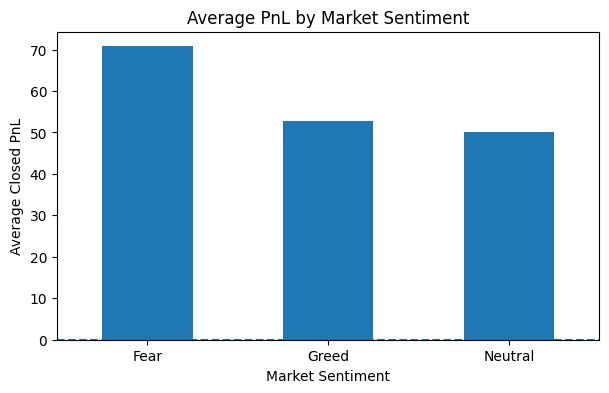

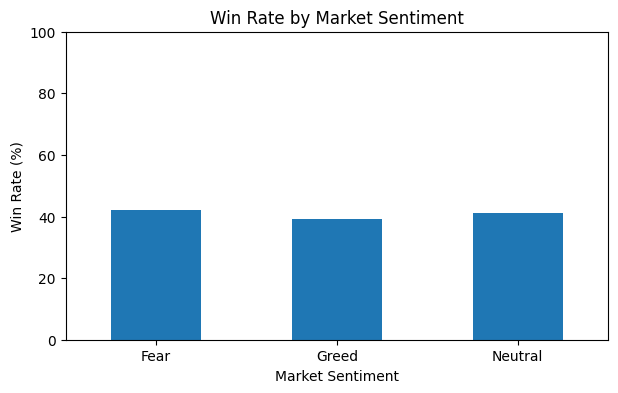

In [ ]:
sentiment_summary[['avg_pnl']].plot(kind='bar', figsize=(7,4), legend=False)
plt.title('Average PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.axhline(0, linestyle='--')
plt.xticks(rotation=0)
plt.show()

sentiment_summary[['win_rate_%']].plot(kind='bar', figsize=(7,4), legend=False)
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

## 5. Long vs Short performance by sentiment

In [ ]:
side_summary = merged_df.groupby(['broad_sentiment', 'side']).agg(
    trades=('closedPnL', 'count'),
    avg_pnl=('closedPnL', 'mean'),
    total_pnl=('closedPnL', 'sum'),
    win_rate=('is_win', 'mean')
).round(3)

side_summary['win_rate_%'] = (side_summary['win_rate'] * 100).round(2)
side_summary = side_summary.drop(columns='win_rate')
side_summary

trades  avg_pnl    total_pnl  win_rate_%
broad_sentiment side                                          
Fear            BUY    23512   84.144  1978391.679        18.8
                SELL   22504   56.791  1278033.848        66.4
Greed           BUY    29086   11.981   348486.826        33.9
                SELL   30286   92.119  2789901.535        44.4
Neutral         BUY    13286   52.664   699693.445        24.8
                SELL   11859   47.072   558222.243        59.5

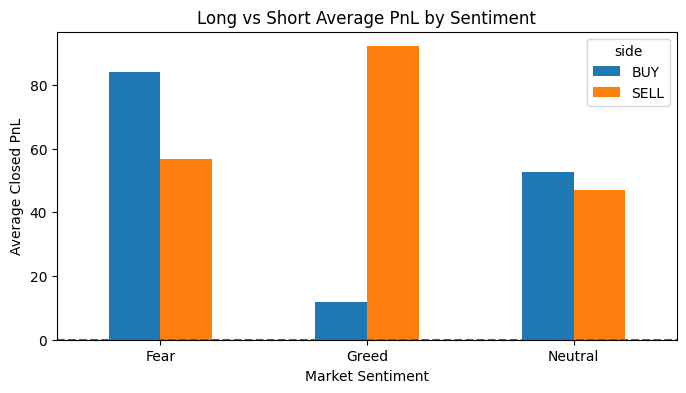

In [ ]:
side_avg = merged_df.groupby(['broad_sentiment', 'side'])['closedPnL'].mean().unstack()
side_avg.plot(kind='bar', figsize=(8,4))
plt.title('Long vs Short Average PnL by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.axhline(0, linestyle='--')
plt.xticks(rotation=0)
plt.show()

## 6. Top and bottom traders

In [ ]:
trader_summary = merged_df.groupby('account').agg(
    total_trades=('closedPnL', 'count'),
    total_pnl=('closedPnL', 'sum'),
    avg_pnl=('closedPnL', 'mean'),
    win_rate=('is_win', 'mean')
).round(3)

trader_summary['win_rate_%'] = (trader_summary['win_rate'] * 100).round(2)
trader_summary = trader_summary.drop(columns='win_rate').sort_values('total_pnl', ascending=False)

print('Top 10 traders')
display(trader_summary.head(10))

print('Bottom 10 traders')
display(trader_summary.tail(10))

Top 10 traders


,total_trades,total_pnl,avg_pnl,win_rate_%
account,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2143382.598,145.482,33.7
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.820,419.128,36.0
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,940163.806,44.364,46.8
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,840422.555,68.684,40.1
0x430f09841d65beb3f27765503d0f850b8bce7713,1237,416541.872,336.736,48.4
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,403011.504,281.826,30.6
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,379095.407,38.320,81.1
0x4f93fead39b70a1824f981a54d4e55b278e9f760,7584,308975.870,40.740,36.0
0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,199505.593,520.902,23.5


Bottom 10 traders


,total_trades,total_pnl,avg_pnl,win_rate_%
account,,,,
0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8519,103343.716,12.131,35.3
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,67845.620,120.507,40.9
0x8381e6d82f1affd39a336e143e081ef7620a3b7f,1911,65513.658,34.282,33.0
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,53496.247,161.133,47.6
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,47885.321,6.578,44.3
0x8477e447846c758f5a675856001ea72298fd9cb5,14998,43917.009,2.928,26.2
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,534,21758.832,40.747,32.2
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1894,1430.782,0.755,35.6
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,-31203.600,-38.287,45.5


## 7. Symbol-wise hidden pattern

In [ ]:
if 'symbol' in merged_df.columns:
    symbol_summary = merged_df.groupby(['symbol', 'broad_sentiment']).agg(
        trades=('closedPnL', 'count'),
        total_pnl=('closedPnL', 'sum'),
        avg_pnl=('closedPnL', 'mean'),
        win_rate=('is_win', 'mean')
    ).round(3)
    symbol_summary['win_rate_%'] = (symbol_summary['win_rate'] * 100).round(2)
    symbol_summary = symbol_summary.drop(columns='win_rate')
    display(symbol_summary.sort_values('total_pnl', ascending=False).head(15))
else:
    print('symbol column not available')

trades    total_pnl  avg_pnl  win_rate_%
symbol  broad_sentiment                                          
@107    Greed              5624  1835331.781  326.339        45.5
HYPE    Fear              22532  1245830.217   55.292        45.2
ETH     Fear               2294   810643.217  353.375        41.5
SOL     Greed              2898   500209.613  172.605        26.2
BTC     Fear               8632   464008.641   53.754        35.6
SOL     Fear                945   455251.085  481.747        43.9
BTC     Greed              8723   270181.645   30.973        32.9
HYPE    Neutral            9998   261186.666   26.124        46.2
        Greed              8569   240669.673   28.086        37.6
SOL     Neutral             951   227358.856  239.073        55.2
@107    Neutral            2739   212886.288   77.724        39.5
MELANIA Fear               1266   175130.521  138.334        34.4
ETH     Neutral            1009   158820.136  157.404        50.6
ZRO     Greed              1160   144174.539  124.288        33.6
BTC     Neutral            4035   124672.060   30.898        32.4

## 8. Leverage / trade-size behavior

In [ ]:
if 'leverage' in merged_df.columns:
    leverage_summary = merged_df.groupby('broad_sentiment').agg(
        avg_leverage=('leverage', 'mean'),
        max_leverage=('leverage', 'max'),
        avg_pnl=('closedPnL', 'mean'),
        win_rate=('is_win', 'mean')
    ).round(3)
    leverage_summary['win_rate_%'] = (leverage_summary['win_rate'] * 100).round(2)
    leverage_summary = leverage_summary.drop(columns='win_rate')
    display(leverage_summary)
elif 'size_usd' in merged_df.columns:
    size_summary = merged_df.groupby('broad_sentiment').agg(
        avg_trade_size=('size_usd', 'mean'),
        total_volume=('size_usd', 'sum'),
        avg_pnl=('closedPnL', 'mean'),
        win_rate=('is_win', 'mean')
    ).round(3)
    size_summary['win_rate_%'] = (size_summary['win_rate'] * 100).round(2)
    size_summary = size_summary.drop(columns='win_rate')
    display(size_summary)
else:
    print('No leverage or size_usd column available')

,avg_trade_size,total_volume,avg_pnl,win_rate_%
broad_sentiment,,,,
Fear,8281.873,3.810987e+08,70.767,42.1
Greed,5605.460,3.328074e+08,52.860,39.3
Neutral,5511.620,1.385897e+08,50.026,41.2


## 9. Time-based trading pattern

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_summary = merged_df.groupby('day_of_week').agg(
    trades=('closedPnL', 'count'),
    avg_pnl=('closedPnL', 'mean'),
    total_pnl=('closedPnL', 'sum'),
    win_rate=('is_win', 'mean')
).reindex(day_order).round(3)

day_summary['win_rate_%'] = (day_summary['win_rate'] * 100).round(2)
day_summary = day_summary.drop(columns='win_rate')
day_summary

,trades,avg_pnl,total_pnl,win_rate_%
day_of_week,,,,
Monday,21300,57.238,1219174.124,42.1
Tuesday,23771,64.552,1534467.360,33.9
Wednesday,24407,50.073,1222125.003,44.2
Thursday,17125,63.140,1081278.476,41.9
Friday,18909,50.951,963440.006,49.5
Saturday,13094,85.556,1120263.904,37.1
Sunday,11927,42.926,511980.704,32.1


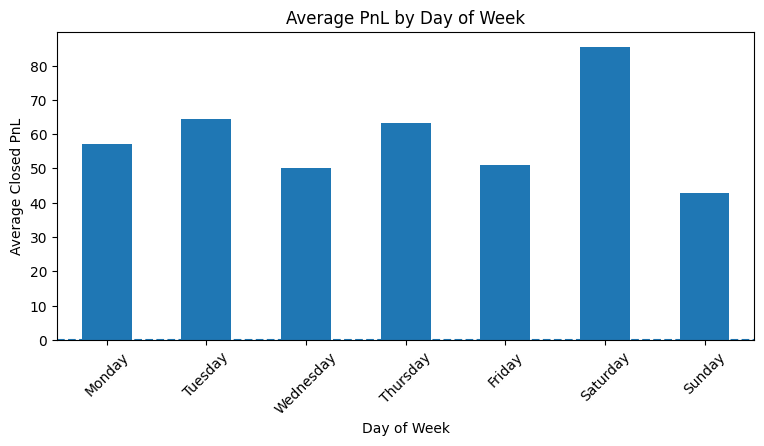

In [ ]:
day_summary['avg_pnl'].plot(kind='bar', figsize=(9,4))
plt.title('Average PnL by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Closed PnL')
plt.axhline(0, linestyle='--')
plt.xticks(rotation=45)
plt.show()

## 10. Final insights and recommendations

In [ ]:
best_sentiment = sentiment_summary['avg_pnl'].idxmax()
worst_sentiment = sentiment_summary['avg_pnl'].idxmin()
best_win_sentiment = sentiment_summary['win_rate_%'].idxmax()

print('FINAL INSIGHTS')
print('-' * 60)
print(f'1. Best average PnL is during: {best_sentiment}')
print(f'2. Worst average PnL is during: {worst_sentiment}')
print(f'3. Highest win rate is during: {best_win_sentiment}')

print('TRADING RECOMMENDATIONS')
print('-' * 60)
print(f'- Traders should study strategies used during {best_sentiment} because average PnL is highest there.')
print(f'- Be more careful during {worst_sentiment} because average PnL is lowest there.')
print('- Compare long and short trades separately because sentiment may affect them differently.')
print('- Monitor position size/leverage during emotional market phases like Fear and Greed.')
print('- Prefer traders or symbols with both high win rate and positive total PnL, not only high trade count.')

FINAL INSIGHTS
------------------------------------------------------------
1. Best average PnL is during: Fear
2. Worst average PnL is during: Neutral
3. Highest win rate is during: Fear
TRADING RECOMMENDATIONS
------------------------------------------------------------
- Traders should study strategies used during Fear because average PnL is highest there.
- Be more careful during Neutral because average PnL is lowest there.
- Compare long and short trades separately because sentiment may affect them differently.
- Monitor position size/leverage during emotional market phases like Fear and Greed.
- Prefer traders or symbols with both high win rate and positive total PnL, not only high trade count.


## 11. Save output files

In [ ]:
merged_df.to_csv('merged_trader_sentiment.csv', index=False)
sentiment_summary.to_csv('sentiment_performance_summary.csv')
trader_summary.to_csv('trader_performance_summary.csv')

print('Saved files:')
print('1. merged_trader_sentiment.csv')
print('2. sentiment_performance_summary.csv')
print('3. trader_performance_summary.csv')

Saved files:
1. merged_trader_sentiment.csv
2. sentiment_performance_summary.csv
3. trader_performance_summary.csv
